# Exercise 1

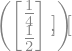

In [4]:
import sympy as smb
from sympy import symbols, Matrix, S, init_printing
init_printing(latex_mode='equation*')
b3 = S.Half**2
c3 = 1
A = Matrix(2,2, [1,1,0,S.Half])
b = Matrix(2,1, [1 - b3, S.Half - b3 * c3])
A.gauss_jordan_solve(b)

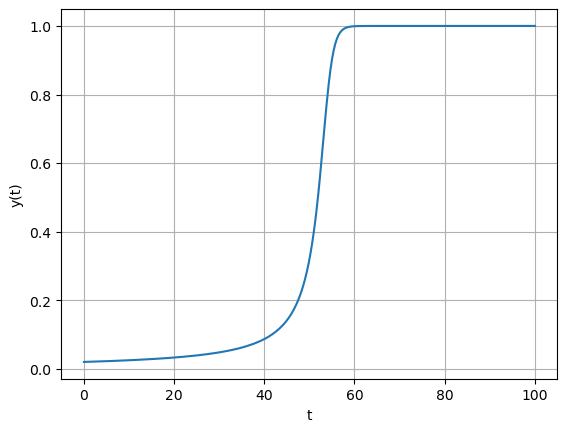

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def f_func(t, y):
    return y**2-y**3


def RK(f_func, t_interval: tuple[float, float], y0: list[float], h0: float, reps: float, aeps: float):
    t0, tf = t_interval
    t = [t0]
    y = y0
    h = h0

    # RK coefficients
    c2, c3 = 1/2, 1
    a21 = 1/2
    a31, a32 = 1/2, 1/2
    b1, b2, b3 = 1/6, 2/3, 1/6

    # Embedded error coefficients
    d1 = 1/6 - 0
    d2 = 2/3 - 1
    d3 = 1/6 - 0

    while t[-1] < tf:
        tn = t[-1]
        yn = y[-1]

        if tn + h > tf:
            h = tf-tn

        while True:
            # stages
            f1 = f_func(tn, yn)
            f2 = f_func(tn + c2*h, yn + a21*h*f1)
            f3 = f_func(tn + c3*h, yn + a31*h*f1 + a32*h*f2)

            # solution
            yn1 = yn + h*(b1*f1 + b2*f2 + b3*f3)

            # error estimate
            err = abs(h*(d1*f1 + d2*f2 + d3*f3))

            tol = reps * abs(yn) + aeps

            if err <= tol:
                break  # accept step

            # reduce step
            h = h/2

        # accept step
        t.append(tn + h)
        y.append(yn1)

        # reset step
        h = h0

    return np.array(t), np.array(y)




delta = 0.02
h0 = 50
reps = 1e-4
aeps = 1e-6

t, y = RK(f_func, (0, 2/delta), [delta], h0, reps, aeps)

plt.plot(t,y)
plt.grid()
plt.ylabel("y(t)")
plt.xlabel("t")
plt.show()

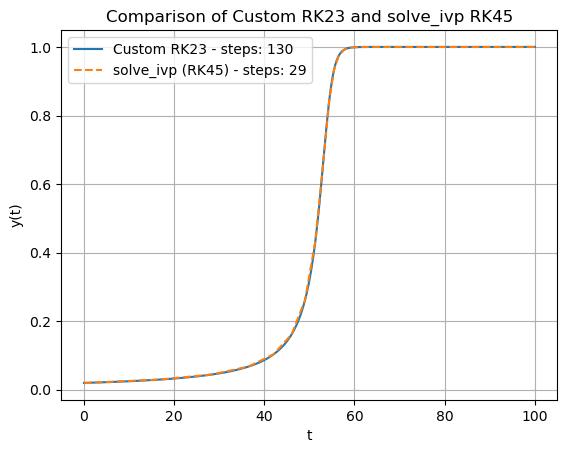

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ODE
def f(t, y):
    return y**2 - y**3

# parameters
delta = 0.02
t0 = 0
tf = 2 / delta
y0 = [delta]

# solve
sol = solve_ivp(
    f,
    (t0, tf),
    y0,
    method='RK45',          # similar to ode45
    rtol=1e-4,             # relative tolerance
    atol=1e-6              # absolute tolerance
)

# plot
plt.plot(t, y, label=f"Custom RK23 - steps: {len(t)-1}")
plt.plot(sol.t, sol.y[0], label=f"solve_ivp (RK45) - steps: {len(sol.t)-1}", linestyle='--')
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.title("Comparison of Custom RK23 and solve_ivp RK45")
plt.show()

In [7]:
(len(t) - 1) * 3, (len(sol.t) - 1) * 6

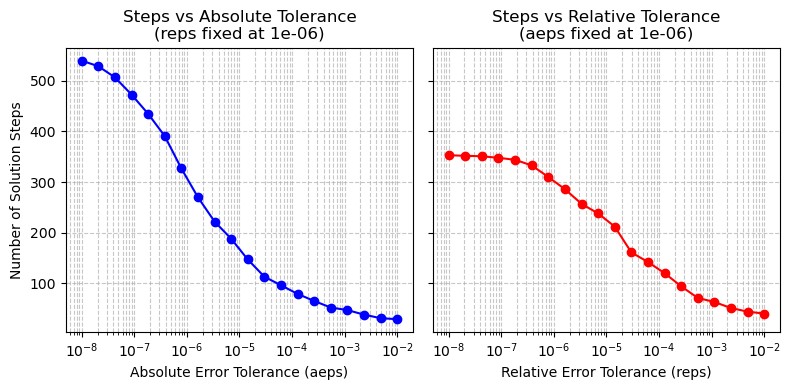

In [16]:
# ODE
def f(t, y):
    return y**2 - y**3

# parameters
delta = 0.02
t0 = 0
tf = 2 / delta
h0 = (tf - t0) / 2 # initial step size

# Vary aeps (absolute tolerance) while keeping reps (relative tolerance) fixed
fixed_reps = 1e-6
aeps_values = np.logspace(-8, -2, 20)
steps_vs_aeps = []

for aeps in aeps_values:
    y0 = [delta]
    # method='RK45' uses the explicit Runge-Kutta method of order 5(4)
    sol = RK(f, (t0, tf), y0, h0, aeps=aeps, reps=fixed_reps)
    steps_vs_aeps.append(len(sol[0]-1))

# Vary reps (relative tolerance) while keeping aeps (absolute tolerance) fixed
fixed_aeps = 1e-6
reps_values = np.logspace(-8, -2, 20)
steps_vs_reps = []

for reps in reps_values:
    y0 = [delta]
    sol = RK(f, (t0, tf), y0, h0, aeps=fixed_aeps, reps=reps)
    steps_vs_reps.append(len(sol[0]-1))

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# Plot 1: Steps vs aeps
ax1.plot(aeps_values, steps_vs_aeps, 'bo-')
ax1.set_xscale('log')  # Log scale makes it much easier to visualize tolerances
ax1.set_xlabel('Absolute Error Tolerance (aeps)')
ax1.set_ylabel('Number of Solution Steps')
ax1.set_title(f'Steps vs Absolute Tolerance\n(reps fixed at {fixed_reps})')
ax1.grid(True, which="both", ls="--", alpha=0.7)

# Plot 2: Steps vs reps
ax2.plot(reps_values, steps_vs_reps, 'ro-')
ax2.set_xscale('log')
ax2.set_xlabel('Relative Error Tolerance (reps)')
ax2.set_title(f'Steps vs Relative Tolerance\n(aeps fixed at {fixed_aeps})')
ax2.grid(True, which="both", ls="--", alpha=0.7)

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


## Convergence rate when using max norm as error measure

ERK2 convergence rate: 1.9942584108351864
ERK3 convergence rate: 2.992183148273682


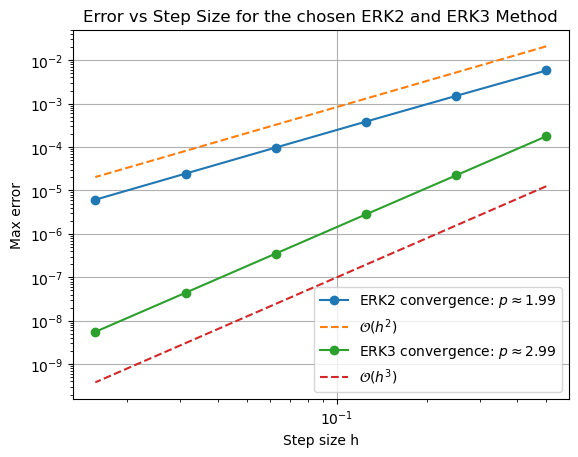

In [9]:
def ERK3_fixed(f_func, t_interval: tuple[float, float], y0: list[float], h0: float):
    t0, tf = t_interval
    t = [t0]
    y = y0
    h = h0

    # RK coefficients
    c2, c3 = 1/2, 1
    a21 = 1/2
    a31, a32 = -1, 2
    b1, b2, b3 = 1/6, 2/3, 1/6

    while t[-1] < tf:
        tn = t[-1]
        yn = y[-1]

        if tn + h > tf:
            h = tf-tn

        # stages
        f1 = f_func(tn, yn)
        f2 = f_func(tn + c2*h, yn + a21*h*f1)
        f3 = f_func(tn + c3*h, yn + a31*h*f1 + a32*h*f2)

        # solution
        yn1 = yn + h*(b1*f1 + b2*f2 + b3*f3)

        # accept step
        t.append(tn + h)
        y.append(yn1)

    return np.array(t), np.array(y)

def ERK2_fixed(f_func, t_interval: tuple[float, float], y0: list[float], h0: float):
    t0, tf = t_interval
    t = [t0]
    y = y0
    h = h0

    # RK coefficients
    c2, c3 = 1/2, 1
    a21 = 1/2
    a31, a32 = -1, 2
    b1, b2, b3 =  0,1,0 #1/4, 1/2, 1/4

    while t[-1] < tf:
        tn = t[-1]
        yn = y[-1]

        if tn + h > tf:
            h = tf-tn

        # stages
        f1 = f_func(tn, yn)
        f2 = f_func(tn + c2*h, yn + a21*h*f1)
        f3 = f_func(tn + c3*h, yn + a31*h*f1 + a32*h*f2)

        # solution
        yn1 = yn + h*(b1*f1 + b2*f2 + b3*f3)

        # accept step
        t.append(tn + h)
        y.append(yn1)

    return np.array(t), np.array(y)

# ODE
def f(t, y):
    return y**2 - y**3

# parameters
delta = 0.02
t0 = 0
tf = 2 / delta
y0 = [delta]


# 1. Ask solve_ivp to build a continuous interpolation function
sol_exact = solve_ivp(f_func, [t0, tf], y0, rtol=1e-12, atol=1e-12, dense_output=True)

h_values = np.array([0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625])
errors2 = []
errors3 = []

for h in h_values:
    y0 = [delta]
    # Get your ERK2 solution and its specific time grid
    t_fixed, y_fixed = ERK2_fixed(f_func, (t0, tf), y0, h)
    
    
    # 2. Sample the exact solution using YOUR time grid
    y_exact_grid = sol_exact.sol(t_fixed)[0]
    
    # 3. Calculate the Max Norm (L_infinity) of the difference
    max_error2 = np.max(np.abs(y_fixed - y_exact_grid))
    
    errors2.append(max_error2)


    y0 = [delta]
    # Get your ERK3 solution and its specific time grid
    t_fixed, y_fixed = ERK3_fixed(f_func, (t0, tf), y0, h)
    
    
    # 2. Sample the exact solution using YOUR time grid
    y_exact_grid = sol_exact.sol(t_fixed)[0]
    
    # 3. Calculate the Max Norm (L_infinity) of the difference
    max_error3 = np.max(np.abs(y_fixed - y_exact_grid))
    
    errors3.append(max_error3)

erk2_convergence_rate = np.polyfit(np.log(h_values[-3:]), np.log(errors2[-3:]), 1)[0]
erk3_convergence_rate = np.polyfit(np.log(h_values[-3:]), np.log(errors3[-3:]), 1)[0]
print(f"ERK2 convergence rate: {erk2_convergence_rate}")  # Estimate slope in log-log plot
print(f"ERK3 convergence rate: {erk3_convergence_rate}")  # Estimate slope in log-log plot

plt.loglog(h_values, errors2, label=rf"ERK2 convergence: $p \approx {erk2_convergence_rate:.2f}$", marker='o')
plt.loglog(h_values, 1/12* h_values**2, '--', label=r"$\mathcal{O}(h^2)$")
plt.loglog(h_values, errors3, label=rf"ERK3 convergence: $p \approx {erk3_convergence_rate:.2f}$", marker='o')
plt.loglog(h_values, 1e-4* h_values**3, '--', label=r"$\mathcal{O}(h^3)$")
plt.xlabel("Step size h")
plt.ylabel("Max error")
plt.title("Error vs Step Size for the chosen ERK2 and ERK3 Method")
plt.grid()
plt.legend()
plt.show()

## Check adaptive method against the ```solve_ivp``` method

In [10]:
''' ====== Setup IVP problem for error comparison with solve_ivp ====== '''
# ODE
def f(t, y):
    return y**2 - y**3

# parameters
delta = 0.02
t0 = 0
tf = 2 / delta
y0 = [delta]

reps = 1e-4
aeps = 1e-6


# 1. Ask solve_ivp to build a continuous interpolation function
sol_exact = solve_ivp(f_func, [t0, tf], y0, rtol=1e-12, atol=1e-12, dense_output=True)

t_23, y_23 = RK(f_func, (t0, tf), y0, h0, reps, aeps)

# 2. Sample the exact solution using YOUR time grid
y_exact_grid = sol_exact.sol(t_23)[0]

# 3. Calculate the Max Norm (L_infinity) of the difference
max_error23 = np.max(np.abs(y_23 - y_exact_grid))
print(f"Max norm error (RK23): {max_error23}")

Max norm error (RK23): 9.421518811159046e-05


## Convergence rate when using last computed value
Intuitively the global error should propagate the the last computed $y$-value at $y(t_1)$, but it seems less rigourus

In [11]:
# parameters
delta = 1e-4
t0 = 0
tf = 2 / delta
y0 = [delta]
h0 = 50

t, y = RK(f_func, t0, tf, y0[0], h0, 1e-4, 1e-6)
print(len(t))
plt.plot(t,y)
plt.ylabel("y(t)")
plt.xlabel("t")
plt.grid()
plt.show()

TypeError: RK() takes 6 positional arguments but 7 were given

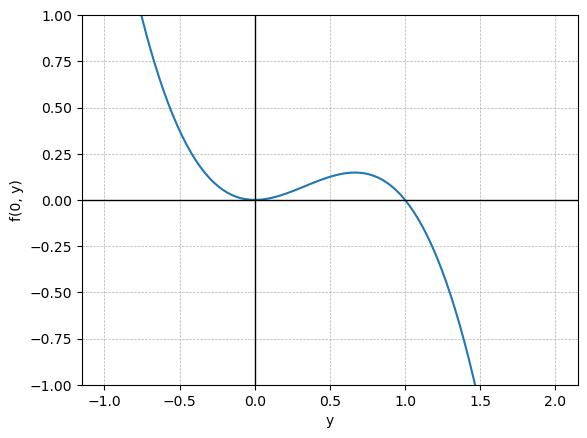

In [ ]:
from matplotlib import lines


y = np.linspace(-1, 2, 100)
f_y = f_func(0, y)
plt.plot(y, f_y)
plt.xlabel("y")
plt.ylabel("f(0, y)")
plt.ylim(-1, 1)
plt.grid(True, which='major', axis='both',  linestyle='--', linewidth=0.5)
plt.axhline(0, color="black", linestyle="-", linewidth=1)
plt.axvline(0, color="black", linestyle="-", linewidth=1)
plt.show()